In [11]:
import numpy as np
import pandas as pd
from sklearn import svm
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(font_scale=1.2)

In [12]:
recipes = pd.read_csv("recipes_muffins_cupcakes.csv")

recipes.head()
recipes.shape

(20, 9)

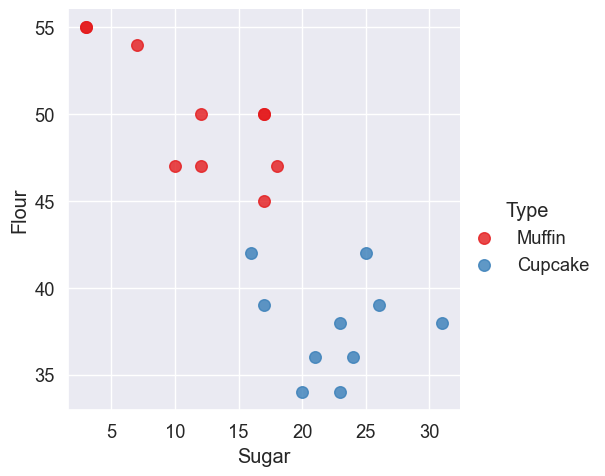

In [13]:
sns.lmplot(x='Sugar', y='Flour', data=recipes, hue='Type',
           palette='Set1', fit_reg=False, scatter_kws={"s":70})

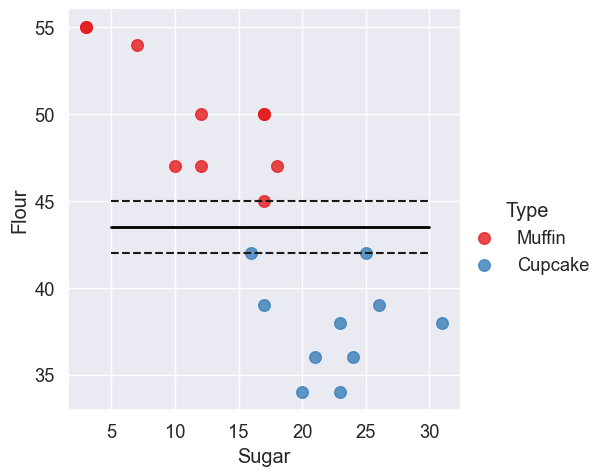

In [18]:
# Prepare data
sugar_flour = recipes[['Sugar','Flour']].values
type_label = np.where(recipes['Type']=='Muffin',0,1)

# Train SVM model
model = svm.SVC(kernel='linear')
model.fit(sugar_flour, type_label)

# Get hyperplane
w = model.coef_[0]
a = -w[0] / w[1]

xx = np.linspace(5,30)
yy = a*xx - (model.intercept_[0] / w[1])

# Support vectors
b = model.support_vectors_[0]
yy_down = a*xx + (b[1] - a*b[0])

b = model.support_vectors_[-1]
yy_up = a*xx + (b[1] - a*b[0])

# Plot decision boundary
sns.lmplot(x='Sugar', y='Flour', data=recipes, hue='Type',
           palette='Set1', fit_reg=False, scatter_kws={"s":70})

plt.plot(xx, yy, linewidth=2, color='black')
plt.plot(xx, yy_down, 'k--')
plt.plot(xx, yy_up, 'k--')

plt.scatter(model.support_vectors_[:,0],
            model.support_vectors_[:,1],
            s=80, facecolors='none')

plt.show()


In [19]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    sugar_flour, type_label, test_size=0.2
)

model1 = svm.SVC(kernel='linear')
model1.fit(x_train, y_train)

pred = model1.predict(x_test)

print(pred)

[1 0 0 0]


In [20]:
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

[[3 0]
 [0 1]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

